In [1]:
import numpy as np
import matplotlib.pyplot as plt
import yapss
from yapss import math
import time as timing
import multiprocessing as mp

mu = 1.2150584270572e-2
C_value = 3.151175879508174
W_v = 1
W_th = 1

def solve_problem(angle):
    start = timing.time()
    problem = yapss.Problem(name="Simple_Cycler", nx=[6], nd = 3)
    mu = 1.2150584270572e-2

    theta = np.radians(angle)
    phi = theta/2

    def objective(arg):
        xi, yi, zi, vxi, vyi, vzi = arg.phase[0].initial_state
        xf, yf, zf, vxf, vyf, vzf = arg.phase[0].final_state
        tgt = [0, math.cos(-theta), math.sin(-theta)]
        c1, c2, c3 = math.cross([vxi, vyi, vzi], [vxf, vyf, vzf])
        t1, t2, t3 = math.cross([vxi, vyi, vzi], tgt)

        r1 = math.sqrt((xf + mu)**2 + yf**2 + zf**2)
        r2 = math.sqrt((xf - 1 + mu)**2 + yf**2 + zf**2)
        U = -0.5*(xf**2 + yf**2) - (1 - mu)/r1 - mu/r2

        Cf = -2*U - (vxf**2 + vyf**2 + vzf**2)
        arg.objective = W_v*(c1**2 + c2**2 + c3**2) + W_th*(t1**2 + t2**2 + t3**2)

    def continuous(arg):
        x, y, z, vx, vy, vz = arg.phase[0].state

        r1 = math.sqrt((x + mu)**2 + y**2 + z**2)
        r2 = math.sqrt((x - 1 + mu)**2 + y**2 + z**2)
        U = -0.5*(x**2 + y**2) - (1 - mu)/r1 - mu/r2

        ax = x - (1 - mu)*(x + mu)/r1**3 - mu*(x - 1 + mu)/r2**3 + 2*vy
        ay = y - (1 - mu)*y/r1**3 - mu*y/r2**3 - 2*vx
        az = -(1 - mu)*z/r1**3 - mu*z/r2**3

        C = -2*U - (vx**2 + vy**2 + vz**2)

        arg.phase[0].dynamics = [vx, vy, vz, ax, ay, az]

    def discrete(arg):
        xi, yi, zi, vxi, vyi, vzi = arg.phase[0].initial_state
        xf, yf, zf, vxf, vyf, vzf = arg.phase[0].final_state
        c1, c2, c3 = math.cross([vxi, vyi, vzi], [vxf, vyf, vzf])
        arg.discrete = [xf-xi, yf-yi, zf-zi]

    problem.functions.objective = objective
    problem.functions.continuous = continuous
    problem.functions.discrete = discrete

    def day_to_gen(t):
        return t*2*math.pi/27.321661
    def gen_to_day(t):
        return t*27.321661/2/math.pi

    bounds = problem.bounds.phase[0]
    bounds.initial_time.lower = bounds.initial_time.upper = 0
    problem.bounds.discrete.lower[:] = problem.bounds.discrete.upper[:] = [0, 0, 0]

    load_tgt = "2dorbit.npz"

    guess_sol = np.load(load_tgt)
    state_guess = guess_sol["state"]
    state_guess_3d = np.zeros(tuple(x + y for x, y in zip(np.shape(state_guess), (2,0))))
    for i in range (np.size(state_guess, 1)):
        xs, ys, vxs, vys = state_guess[:,i]
        xsf = xs
        ysf = ys - 2*ys*math.sin(phi)**2
        zsf = 2*ys*math.sin(phi)*math.cos(phi)
        vxsf = vxs
        vysf = vys - 2*vys*math.sin(phi)**2
        vzsf = 2*vys*math.sin(phi)*math.cos(phi)
        state_guess_3d[:,i] = [xsf, ysf, zsf, vxsf, vysf, vzsf]

    time_guess = guess_sol["time"]

    phase = problem.guess.phase[0]
    phase.time = time_guess
    phase.state = state_guess_3d

    problem.derivatives.method = "auto"
    problem.derivatives.order = "second"
    problem.spectral_method = "lgl"
    segments, points = 100, 10
    problem.mesh.phase[0].collocation_points = segments*[points]
    problem.mesh.phase[0].fraction = segments*[1/segments]

    problem.ipopt_options.mu_strategy = "adaptive"
    problem.ipopt_options.print_level = 3
    problem.ipopt_options.print_user_options = "yes"
    problem.ipopt_options.timing_statistics = "yes"
    problem.ipopt_options.sb = "yes"
    problem.ipopt_options.tol = 1e-8

    solution = problem.solve()
    solve_time = timing.time() - start

    return solve_time, solution

max_time = 30

In [ ]:
step = 1
initial = 1
for angle in range(initial, 90, step):

    print("\n Degree Target", angle)

    solve_time, solution = solve_problem(angle)

    state = solution.phase[0].state
    time = solution.phase[0].time
    control = solution.phase[0].control
    time_c = solution.phase[0].time_c
    t0 = solution.phase[0].initial_time
    tf = solution.phase[0].final_time
    x, y, z, vx, vy, vz = state

    print("Solve Time", solve_time)
    print("Orbit Period (nondimensional time)", tf)
    print("Difference in final x position", x[0] - x[-1])
    print("Difference in final y position", y[0] - y[-1])
    print("Difference in final z position", z[0] - z[-1])
    print("Difference in final x velocity", vx[0] - vx[-1])
    print("Difference in final y velocity", vy[0] - vy[-1])
    print("Difference in final z velocity", vz[0] - vz[-1])
    print("Velocity Cross Product", math.cross([vx[0], vy[0], vz[0]], [vx[-1], vy[-1], vz[-1]]))
    def U(x, y, z):
        r1 = math.sqrt((x + mu)**2 + y**2 + z**2)
        r2 = math.sqrt((x - 1 + mu)**2 + y**2 + z**2)
        return -0.5*(x**2 + y**2) - (1 - mu)/r1 - mu/r2

    C_vals = np.zeros((len(x), 1))
    for i in range (len(x)):
        C_vals[i] = -2*U(x[i], y[i], z[i]) - (vx[i]**2 + vy[i]**2 + vz[i]**2)
    C_err = np.ptp(C_vals) # Maximum Jacobi constant deviation
    print("Maximum Jacobi Constant Deviation", C_err)
    hamiltonian = solution.phase[0].hamiltonian
    hamil_dev = np.ptp(hamiltonian)
    print("Maximum Hamiltonian Deviation", hamil_dev)
    print("Angle", math.rad2deg(math.arccos(math.dot([vy[0], vz[0]], [-1, 0])/math.sqrt(vy[0]**2 + vz[0]**2))))

    name = f"tgts_{angle}"
    np.savez(
        name,
        state = state,
        time = time,
        C_vals = C_vals,
        hamiltonian = hamiltonian
    )


 Degree Target 1
Solve Time 5.420835971832275
Orbit Period (nondimensional time) 9.800403388291368
Difference in final x position 0.0
Difference in final y position 0.0
Difference in final z position 0.0
Difference in final x velocity -1.1496725340587083e-11
Difference in final y velocity -2.4147350785597155e-15
Difference in final z velocity -3.655769263699593e-13
Velocity Cross Product [-7.50001190e-14  4.11650688e-14  2.35834521e-12]
Maximum Jacobi Constant Deviation 1.0480638579224433e-10
Maximum Hamiltonian Deviation 5.881328652868691e-16
Angle 1.0000000000090123

 Degree Target 2
Solve Time 229.04559326171875
Orbit Period (nondimensional time) 5.737011098025163
Difference in final x position 0.0
Difference in final y position 0.0
Difference in final z position 0.0
Difference in final x velocity -2.9944631691709127e-12
Difference in final y velocity -0.012889739807033118
Difference in final z velocity 0.00045011965703289913
Velocity Cross Product [-1.42216412e-11 -5.93486826e-14 

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Maximum Z Error 2.1499671148968984


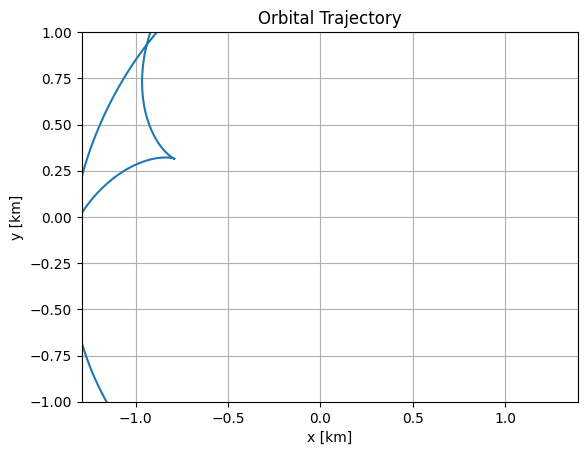

In [3]:
plt.figure()
plt.plot(x, y)
plt.axis("equal")
plt.xlim([-1.1, 1.2])
plt.ylim([-1, 1])
plt.xlabel("x [km]")
plt.ylabel("y [km]")
plt.title("Orbital Trajectory")
plt.grid(True)
z_err = np.max(np.abs(z)) # Maximum z error
print("Maximum Z Error", z_err)

In [4]:
t_tick_days = np.arange(0, 45, 1)
t_tick = day_to_gen(t_tick_days)

from scipy.interpolate import interp1d

fx = interp1d(time, x, kind='cubic', bounds_error=False, fill_value="extrapolate")
fy = interp1d(time, y, kind='cubic', bounds_error=False, fill_value="extrapolate")

x_ticks = fx(t_tick)
y_ticks = fy(t_tick)

plt.figure()
plt.plot(x, y)
plt.axis("equal")
plt.xlim([-1.1, 1.2])
plt.ylim([-1, 1])
plt.xlabel("x [km]")
plt.ylabel("y [km]")
plt.title("Orbital Trajectory")
plt.scatter(x_ticks, y_ticks, marker='+', color='blue')
plt.grid(True)

NameError: name 'day_to_gen' is not defined

In [ ]:
print("Error [seconds]", abs(gen_to_day(tf) - 44.7538)*24*60*60)       # seconds off from period stated in paper
print("Error [%]", abs(gen_to_day(tf) - 44.7538)/44.7538*100)  # days off expressed as a percent

Error [seconds] 184718.65358753703
Error [%] 4.777130387777982


In [ ]:
def U(x, y, z):
    r1 = math.sqrt((x + mu)**2 + y**2 + z**2)
    r2 = math.sqrt((x - 1 + mu)**2 + y**2 + z**2)
    return -0.5*(x**2 + y**2) - (1 - mu)/r1 - mu/r2

C_vals = np.zeros((len(x), 1))
for i in range (len(x)):
    C_vals[i] = -2*U(x[i], y[i], z[i]) - (vx[i]**2 + vy[i]**2 + vz[i]**2)
C_err = np.ptp(C_vals) # Maximum Jacobi constant deviation
print("Maximum Jacobi Constant Deviation", C_err)

Maximum Jacobi Constant Deviation 1.0480638579224433e-10


Jacobi Mean Difference from Ideal 0.0038697493033361674


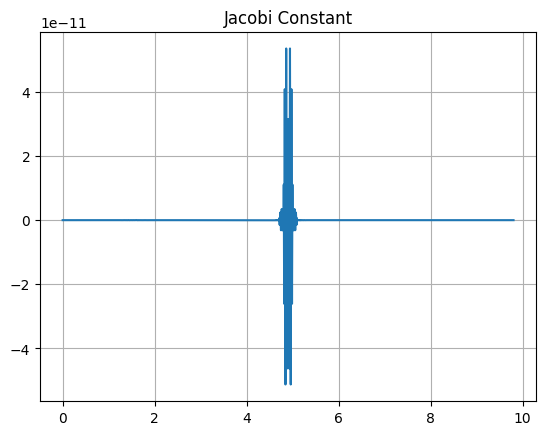

In [ ]:
C_mean = np.mean(C_vals)
print("Jacobi Mean Difference from Ideal", math.abs(C_mean - C_value))
plt.figure()
plt.plot(time, (C_vals - C_mean))
plt.title("Jacobi Constant")
plt.grid(True)

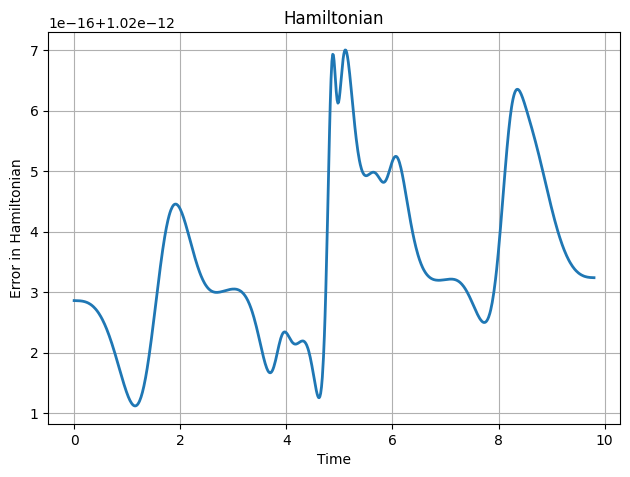

Maximum Hamiltonian Deviation 5.881328652868691e-16


In [ ]:
hamiltonian = solution.phase[0].hamiltonian

plt.figure()
plt.plot(time, hamiltonian, linewidth=2)
plt.xlabel("Time")
plt.ylabel(r"Error in Hamiltonian")
plt.tight_layout()
plt.title("Hamiltonian")
plt.autoscale(axis='y')
plt.grid(True)
plt.show()

hamil_dev = np.ptp(hamiltonian)
print("Maximum Hamiltonian Deviation", hamil_dev)

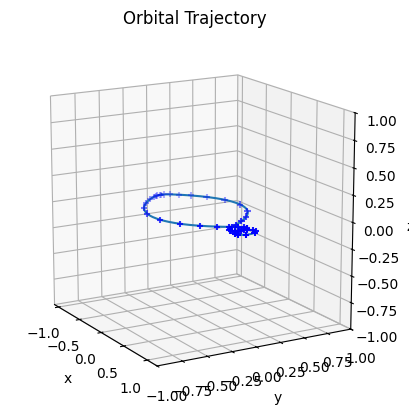

In [ ]:
t_tick_days = np.arange(0, 45, 1)
t_tick = day_to_gen(t_tick_days)

from scipy.interpolate import interp1d

fx = interp1d(time, x, kind='cubic', bounds_error=False, fill_value="extrapolate")
fy = interp1d(time, y, kind='cubic', bounds_error=False, fill_value="extrapolate")
fz = interp1d(time, z, kind='cubic', bounds_error=False, fill_value="extrapolate")

x_ticks = fx(t_tick)
y_ticks = fy(t_tick)
z_ticks = fz(t_tick)

fig_3d = plt.figure()
ax = fig_3d.add_subplot(111, projection='3d')
plt.plot(x, y, z)
ax.set_box_aspect([1, 1, 1])
ax.set_xlim([-1.1, 1.2])
ax.set_ylim([-1, 1])
ax.set_zlim([-1, 1])
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.scatter3D(x_ticks, y_ticks, z_ticks, marker='+', color='blue')
plt.title("Orbital Trajectory")
plt.grid(True)
ax.view_init(elev=30, azim=-60)
ax.view_init(elev=15, azim=-30)